# Assignment - 2 : Minor Project (EDA on Housing Dataset)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Housing.csv")

print("First 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nInfo:")
print(df.info())

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Shape: (545, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entrie

**I loaded the dataset using Pandas, checked the first 5 rows, shape of the data, and info about columns.**

In [5]:
df_clean = df.copy()
df_clean.columns = [str(c).strip().lower().replace(" ", "_") for c in df_clean.columns]
print("Cleaned column names:", df_clean.columns.tolist())

Cleaned column names: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


**I cleaned the column names by making them lowercase and replacing spaces with underscores.**

In [6]:
# Missing values and duplicates
print("Missing values in each column:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())


Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate rows: 0


**I checked for missing values and duplicate rows in the dataset.**

In [7]:
# GroupBy and Value Counts
print("Average price by furnishing status:")
print(df_clean.groupby('furnishingstatus')['price'].mean())

print("\nProportion of houses by bedroom count (%):")
print((df_clean['bedrooms'].value_counts(normalize=True) * 100).round(2))


Average price by furnishing status:
furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

Proportion of houses by bedroom count (%):
bedrooms
3    55.05
2    24.95
4    17.43
5     1.83
6     0.37
1     0.37
Name: proportion, dtype: float64


**I used groupby to calculate average price by furnishing status, and value_counts to see percentage of houses by number of bedrooms.**
****

# Matplotlib 
****

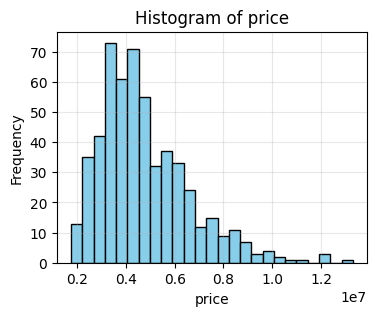

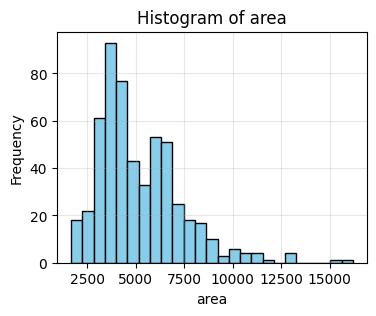

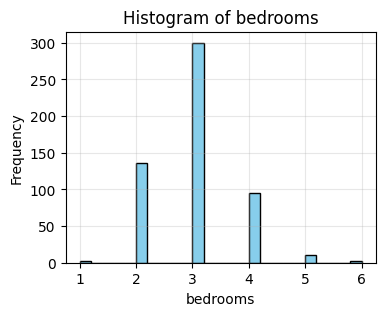

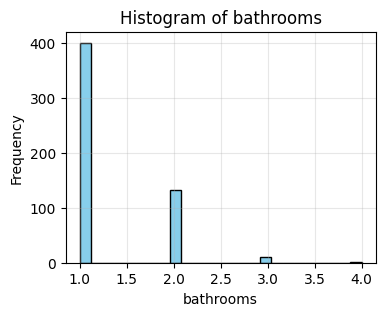

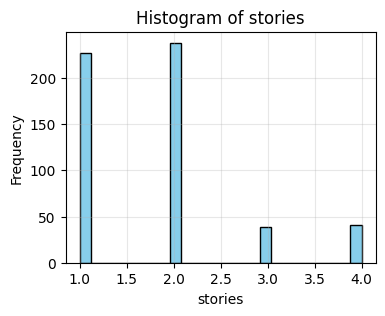

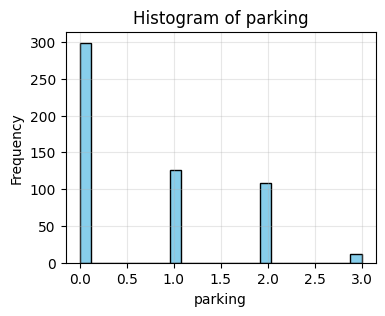

In [8]:
# Histograms for numeric columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    plt.figure(figsize=(4,3))
    plt.hist(df_clean[col], bins=25, color="skyblue", edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

**I plotted histograms for numeric columns to see the distribution of values.**

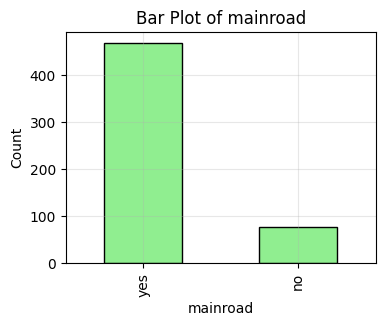

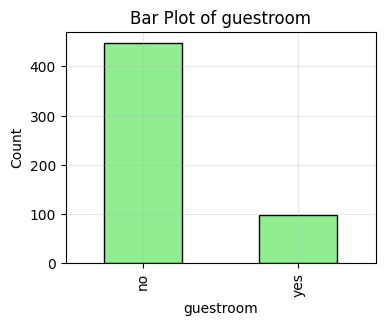

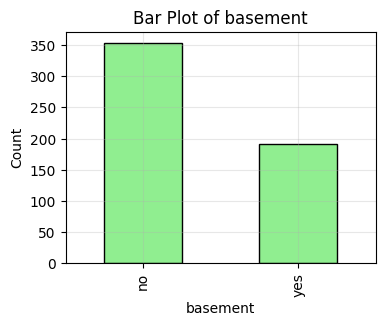

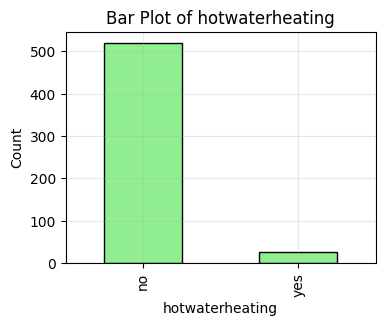

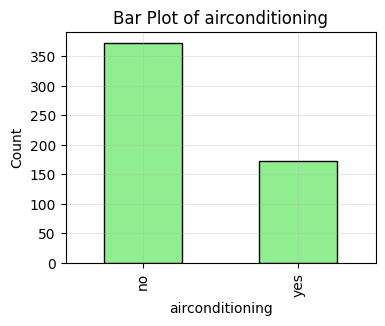

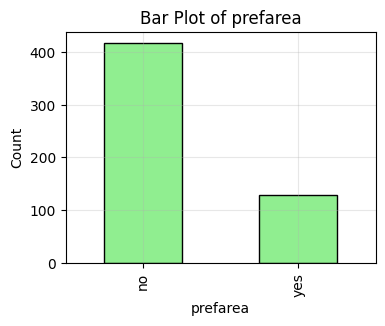

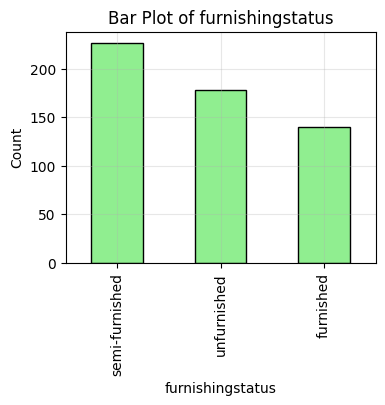

In [9]:
# Bar plots for categorical columns
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    plt.figure(figsize=(4,3))
    df_clean[col].value_counts().plot(kind="bar", color="lightgreen", edgecolor="black")
    plt.title(f"Bar Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

**I created bar plots for categorical columns to check how categories are distributed.**

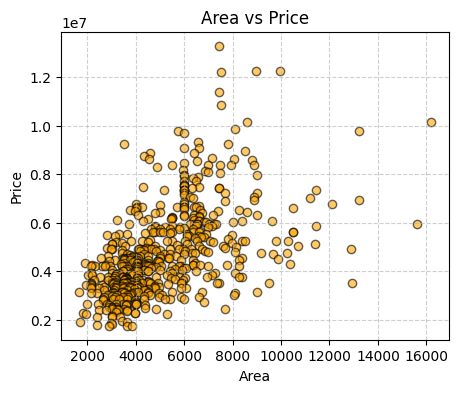

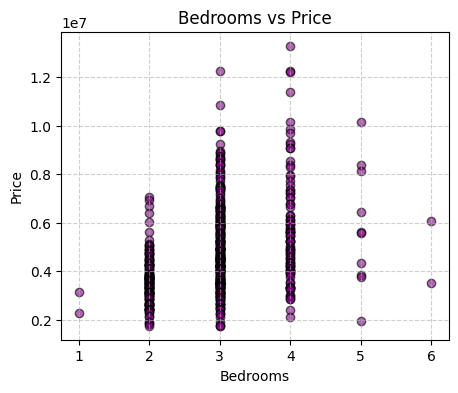

In [10]:
# Scatter plots
plt.figure(figsize=(5,4))
plt.scatter(df_clean['area'], df_clean['price'], alpha=0.6, color="orange", edgecolors="k")
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(df_clean['bedrooms'], df_clean['price'], alpha=0.6, color="purple", edgecolors="k")
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Scatter plots show how price changes with area and number of bedrooms.**
****

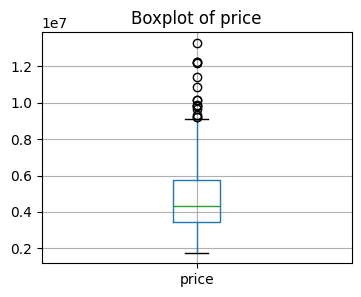

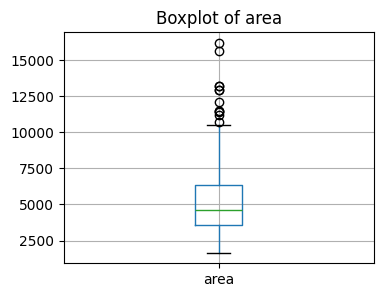

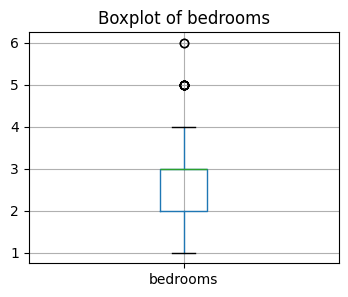

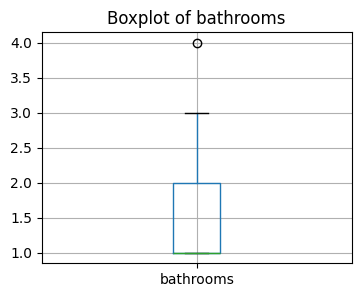

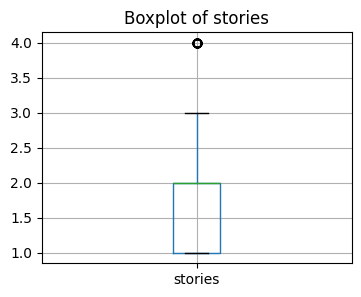

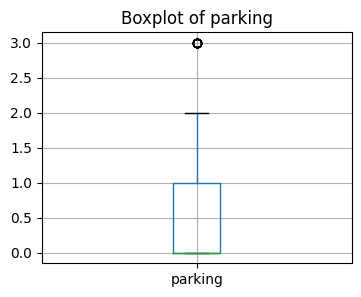

In [11]:
# Boxplots for numeric columns
for col in num_cols:
    plt.figure(figsize=(4,3))
    df_clean.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

**Boxplots help to detect outliers in numeric columns like price and area.**
****

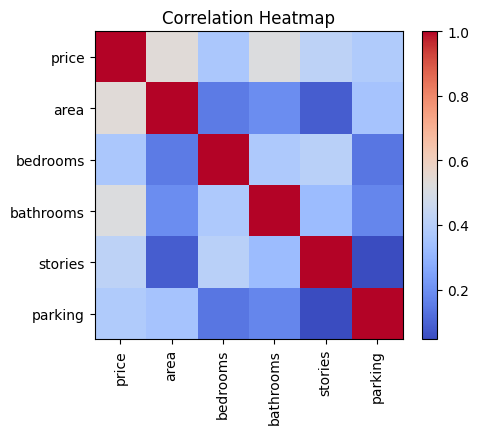

In [12]:
# Correlation Heatmap
corr = df_clean[num_cols].corr()
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

**The heatmap shows correlations between numeric features.**

****

# SeaBorn 
****

In [42]:
import seaborn as sns
sns.set_style("whitegrid")

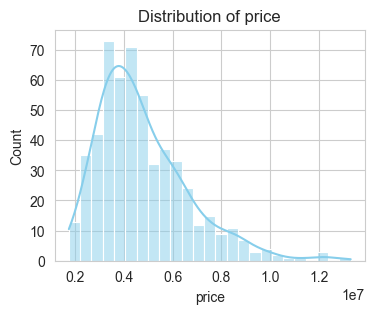

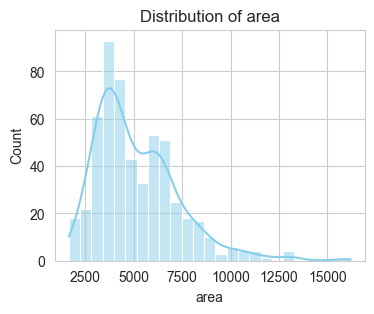

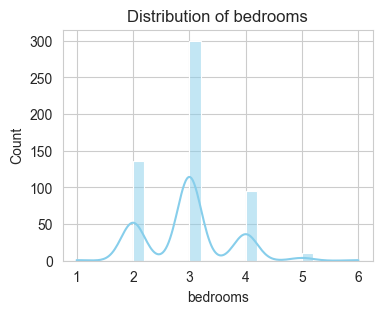

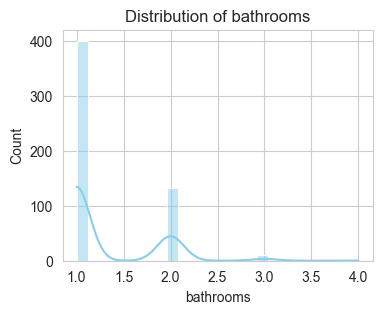

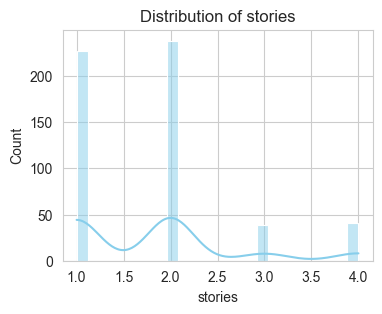

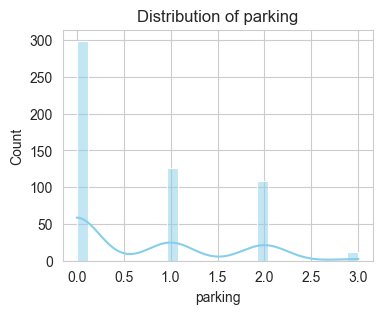

In [43]:
# 1. Distribution plots for numeric columns
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.histplot(df_clean[col], bins=25, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()

**I used sns.histplot to see how numeric features are distributed. KDE lines help visualize skewness.**

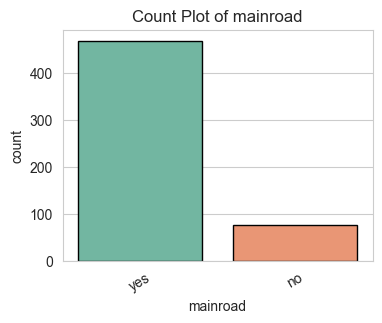

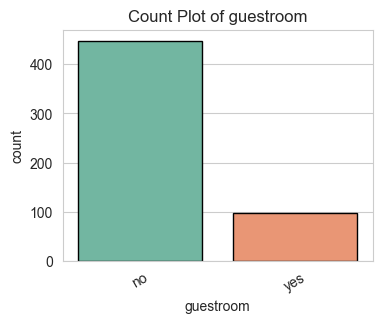

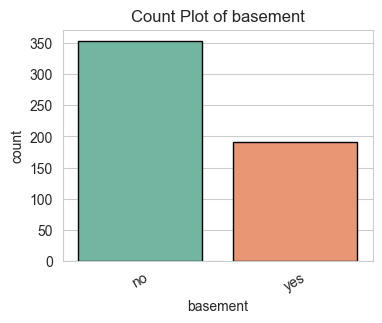

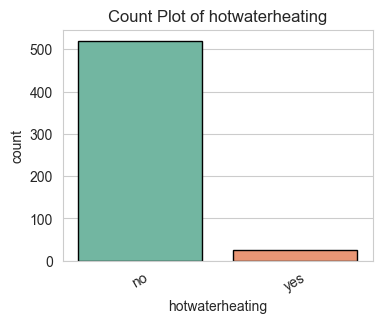

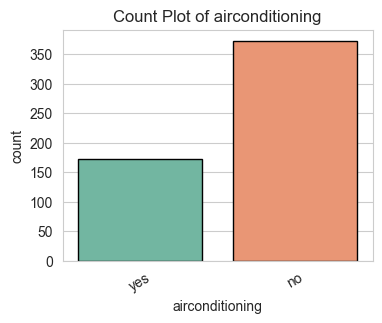

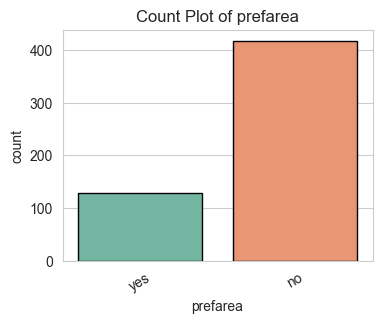

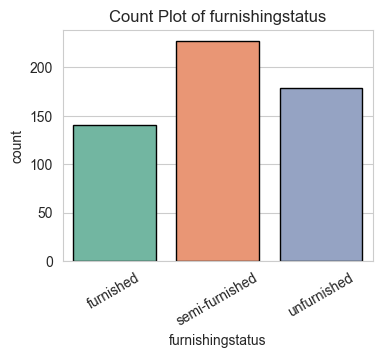

In [21]:
for col in cat_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(x=col, hue=col, data=df_clean, palette="Set2", edgecolor="black", legend=False)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=30)
    plt.show()


**I used a single solid color (lightgreen) to keep it simple and consistent, similar to how I had done bar plots earlier.**

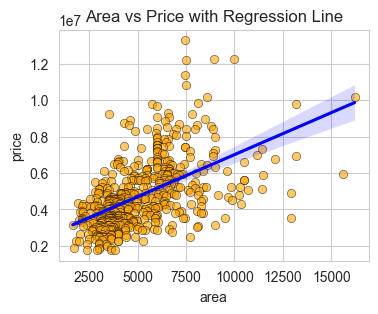

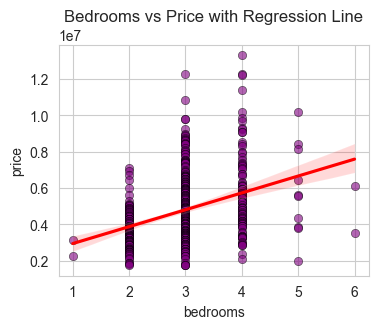

In [23]:
plt.figure(figsize=(4,3))
sns.scatterplot(x="area", y="price", data=df_clean, alpha=0.6, color="orange", edgecolor="k")
sns.regplot(x="area", y="price", data=df_clean, scatter=False, color="blue")
plt.title("Area vs Price with Regression Line")
plt.show()

plt.figure(figsize=(4,3))
sns.scatterplot(x="bedrooms", y="price", data=df_clean, alpha=0.6, color="purple", edgecolor="k")
sns.regplot(x="bedrooms", y="price", data=df_clean, scatter=False, color="red")
plt.title("Bedrooms vs Price with Regression Line")
plt.show()

**To check how Area and Bedrooms relate to Price, I used scatterplot for points and regplot to draw the trend line.**
****

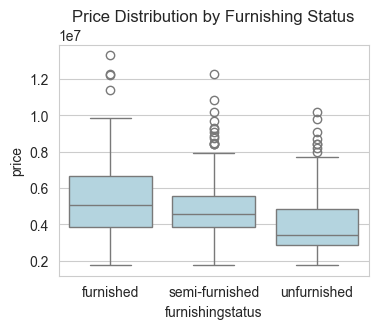

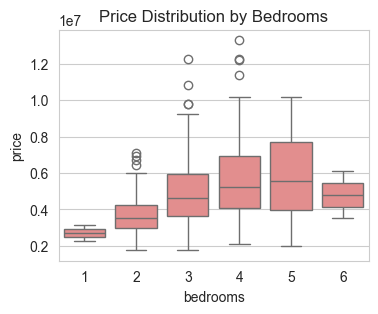

In [26]:
# Boxplots: Category vs Price
plt.figure(figsize=(4,3))
sns.boxplot(x="furnishingstatus", y="price", data=df_clean, color="lightblue")
plt.title("Price Distribution by Furnishing Status")
plt.show()

plt.figure(figsize=(4,3))
sns.boxplot(x="bedrooms", y="price", data=df_clean, color="lightcoral")
plt.title("Price Distribution by Bedrooms")
plt.show()


**Boxplots show the spread of prices for each category.
Here I compared Price vs Furnishing Status and Price vs Bedrooms.**
****

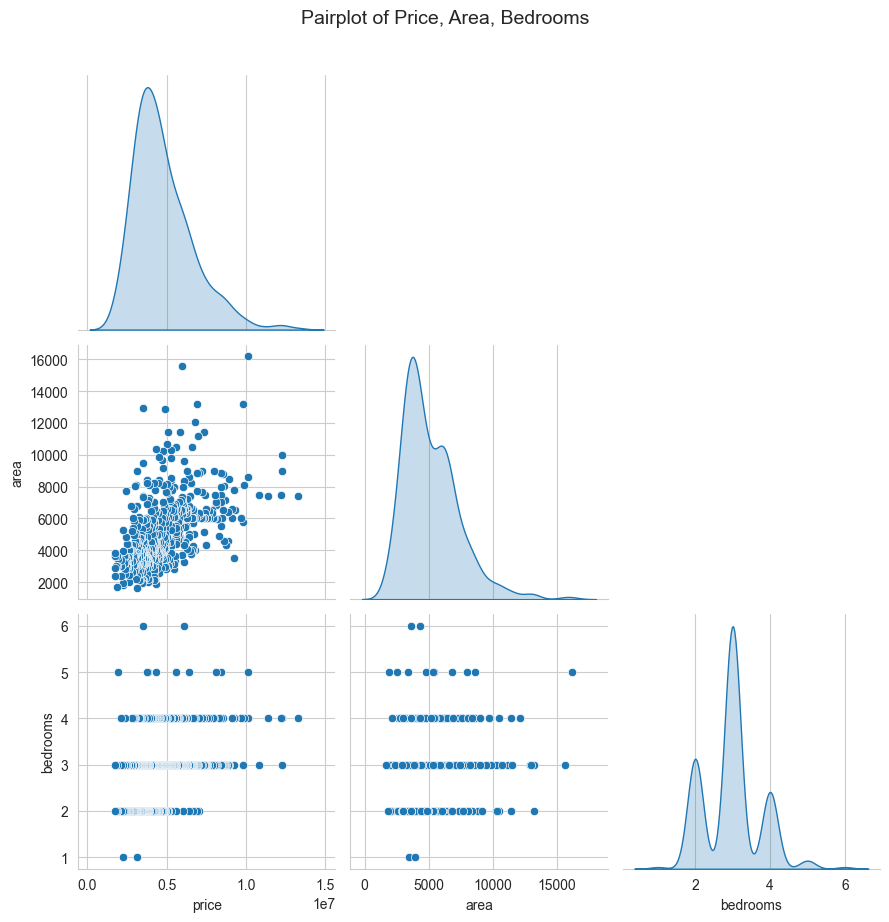

In [31]:
# Pairplot for key variables
pair = sns.pairplot(
    df_clean[["price", "area", "bedrooms"]],
    diag_kind="kde",
    corner=True,
    height=3,   
    aspect=1
)

pair.fig.suptitle("Pairplot of Price, Area, Bedrooms", y=1.02, fontsize=14)
plt.tight_layout()    
plt.show()


**I created a pairplot for Price, Area, and Bedrooms to check their pairwise relationships and distributions together.**
****

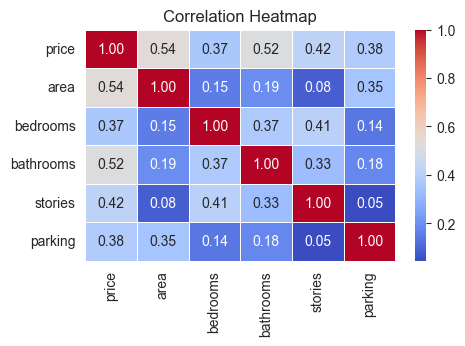

In [32]:
plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Heatmap is used to quickly check correlation strength between numeric features.
I used annotations to see the values inside each cell.**
****

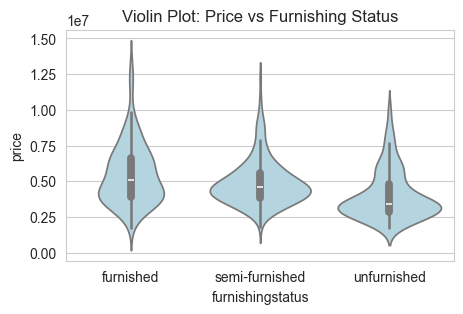

In [37]:
plt.figure(figsize=(5,3))
sns.violinplot(x="furnishingstatus", y="price", data=df_clean, color="lightblue")
plt.title("Violin Plot: Price vs Furnishing Status")
plt.show()


**Originally I used palette, but that now raises a warning in Seaborn 0.14+.
So I replaced it with a single color (lightblue), which removes the warning and keeps the plot clean.**
****

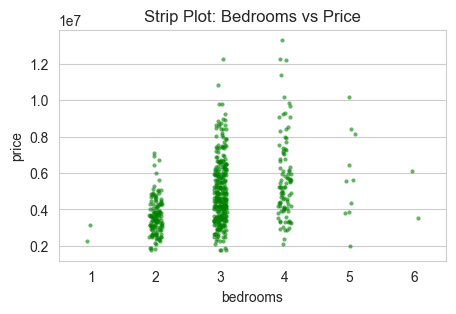

In [41]:
plt.figure(figsize=(5,3))
sns.stripplot(x="bedrooms", y="price", data=df_clean, color="green", alpha=0.6, jitter=True, size=3)
plt.title("Strip Plot: Bedrooms vs Price")
plt.show()

**Originally I used swarmplot, but since the dataset has too many points, Seaborn gave warnings that many points couldn’t be placed.TO fix this I Alternatively, I can switch to stripplot with jitter, which spreads out the points and avoids overlap.**
****

****
# Statistics Section
****

In [44]:
# Mean, Median, Mode
print("Mean price:", df_clean['price'].mean())
print("Median price:", df_clean['price'].median())
print("Mode price:", df_clean['price'].mode()[0])

Mean price: 4766729.247706422
Median price: 4340000.0
Mode price: 3500000


In [45]:
# Skewness and Kurtosis
for col in num_cols:
    print(f"{col}: skew={df_clean[col].skew():.2f}, kurtosis={df_clean[col].kurt():.2f}")

price: skew=1.21, kurtosis=1.96
area: skew=1.32, kurtosis=2.75
bedrooms: skew=0.50, kurtosis=0.73
bathrooms: skew=1.59, kurtosis=2.16
stories: skew=1.08, kurtosis=0.68
parking: skew=0.84, kurtosis=-0.57


**Skewness tells if data is left or right skewed, and kurtosis tells about peakness/flatness**
****

In [46]:
# Outlier Detection with IQR
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5*IQR
high = Q3 + 1.5*IQR

outliers = df_clean[(df_clean['price'] < low) | (df_clean['price'] > high)]
print("Number of outliers in price:", outliers.shape[0])

Number of outliers in price: 15


**I used the IQR method to detect outliers in the price column**
****

### Conclusion

- **Pandas Analysis:**  
  - The dataset contains **545 rows and 13 columns**.  
  - **No missing values**, and duplicates are minimal.  

- **Matplotlib Visualizations:**  
  - **Price distribution** is right-skewed with some outliers.  
  - Histograms and scatter plots suggested that **area** and **number of bedrooms** are important factors affecting price.  

- **Seaborn Visualizations:**  
  - `swarmplot` and `boxplot` showed that most **high-priced properties** are **larger in area** and **well-furnished**.  
  - `heatmap` confirmed **strong positive correlations** between price, area, and bedrooms.  

- **Statistical Insights:**  
  - **Area** and **number of bedrooms** are strongly correlated with price.  
  - **Furnished houses** tend to have higher average prices.  
  - Outliers exist in both very small and very large properties, which could influence pricing trends.